In [62]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Leitura do arquivo

arquivo = 'iron1E15_array'

df = pl.read_csv(arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("count"))

df

column_1,split_column,TRIG,count
str,list[str],str,i64
"""TRIG1 0""","[""TRIG1"", ""0""]","""TRIG1""",0
"""TRIG2 0""","[""TRIG2"", ""0""]","""TRIG2""",0
"""TRIG3 0""","[""TRIG3"", ""0""]","""TRIG3""",0
"""TRIG4 0""","[""TRIG4"", ""0""]","""TRIG4""",0
"""TRIG5 1""","[""TRIG5"", ""1""]","""TRIG5""",1
"""TRIG6 0""","[""TRIG6"", ""0""]","""TRIG6""",0
"""TRIG7 1""","[""TRIG7"", ""1""]","""TRIG7""",1
"""TRIG8 0""","[""TRIG8"", ""0""]","""TRIG8""",0
"""TRIG9 1""","[""TRIG9"", ""1""]","""TRIG9""",1


In [64]:
import re
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Iron 1E15'

In [65]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col("count")).sort(
    pl.col("TRIG").str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
df2 = df2.with_columns(mean_count = pl.col('count').list.mean())  
df2

TRIG,count,mean_count
str,list[i64],f64
"""TRIG1""","[0, 0, … 0]",0.25
"""TRIG2""","[0, 0, … 1]",0.25
"""TRIG3""","[0, 0, … 1]",0.29
"""TRIG4""","[0, 0, … 0]",0.41
"""TRIG5""","[1, 1, … 0]",0.52
"""TRIG6""","[0, 1, … 1]",0.55
"""TRIG7""","[1, 0, … 3]",0.54
"""TRIG8""","[0, 0, … 1]",0.41
"""TRIG9""","[1, 0, … 1]",0.34


In [66]:
# Lista dos TRIGS com valores da média 

trigs = df2['mean_count'].to_list()

In [67]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35.
 -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.
  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
 -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45.]
y_det: [-45. -45. -45. -45. -45. -45. -45. -45. -45. -45. -35. -35. -35. -35.
 -35. -35. -35. -35. -35. -35. -25. -25. -25. -25. -25. -25. -25. -25.
 -25. -25. -15. -15. -15. -15. -15. -15. -15. -15. -15. -15.  -5.  -5.
  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.   5.   5.   5.   5.   5.   5.
   5.   5.   5.   5.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.
  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  35.  35.  35.  35.
  35.  35.  35.  35.  35.  35.  45.  45.  45.  45. 

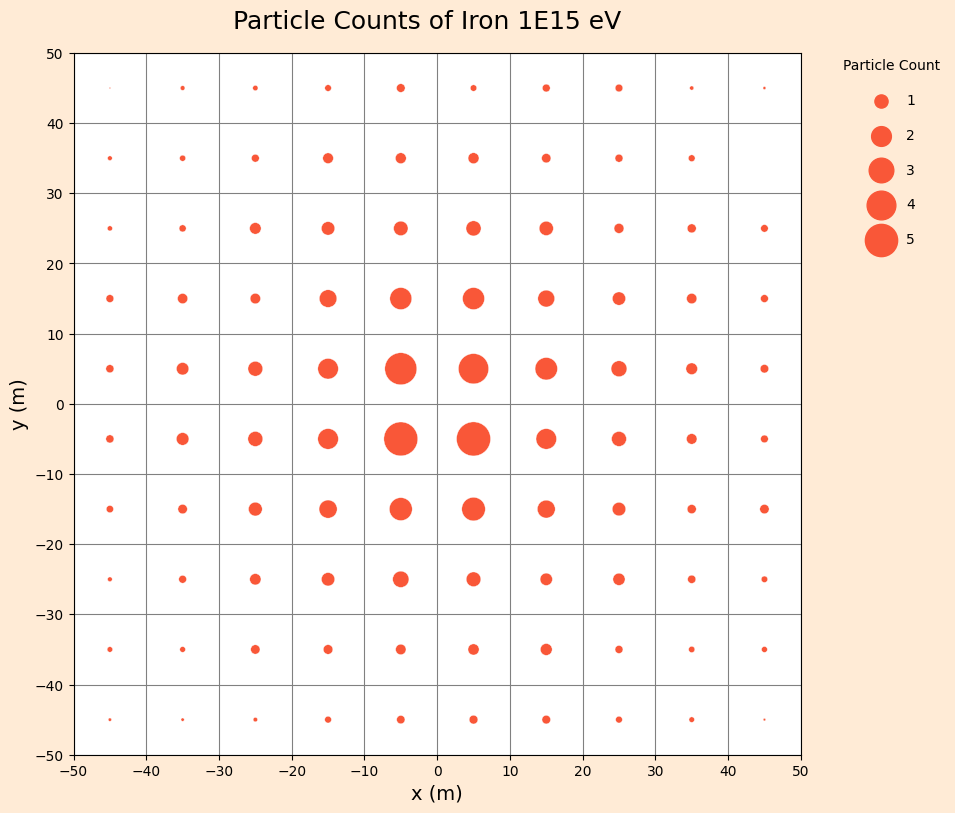

In [68]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/counts_' + str(arquivo) + '.png', bbox_inches = 'tight', dpi = 300)

In [69]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

/tmp/ipykernel_15409/1783382879.py:2: RuntimeWarning: invalid value encountered in scalar divide
  df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])


nan

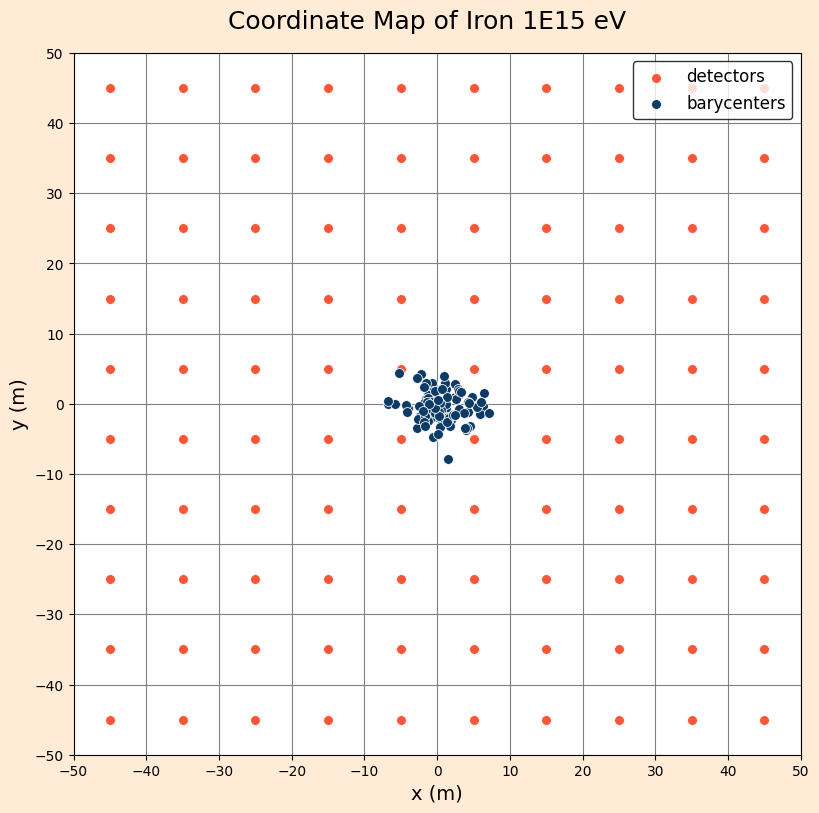

In [70]:
# Posição dos baricentros
x_b = [0] * len(trigs)
y_b = [0] * len(trigs)

for i in range(len(trigs)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (df2['count'][j][i]*x_det[j])
                numerator1 += (df2['count'][j][i]*y_det[j])
                denominator += (df2['count'][j][i])
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight', dpi = 300)

In [71]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = []
for i in range(100):
    aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    r_b.append(aux)


df3 = df2.with_columns(
    pl.Series(name='x_b', values=x_b),
    pl.Series(name='y_b', values=y_b),
    pl.Series(name='r_b', values=r_b)
)

df3 = df3.drop('count')
df3.write_csv('array_dat/' + arquivo + '_fdl.csv', separator= '\t', has_header= False)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


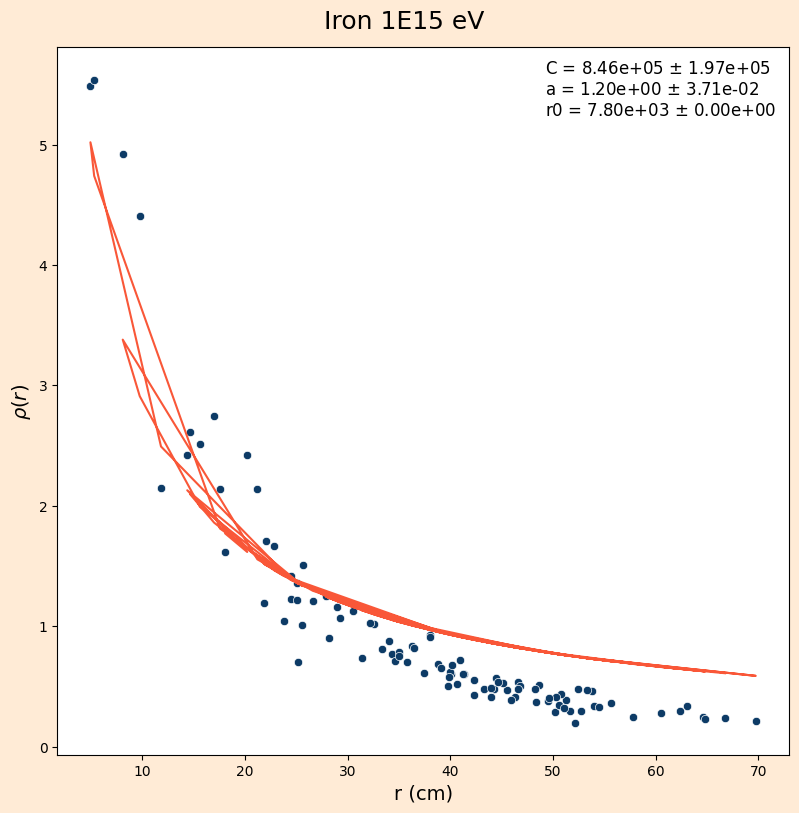

In [72]:
# Essa modelagem não está certa!
from scipy.optimize import curve_fit
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle(str(name) + ' eV', size = 18)
sns.scatterplot(x = r_b, y = df2['mean_count'], ax = ax, color = '#0D3B66')
fig.tight_layout()

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho(r)$', size = 14)

#ax.set_xlim(xmin=0)
#ax.set_ylim(ymin=0)
r_b = np.array(r_b)

r0 = 7800
p0 = (1000,1.334)
def f_model(x, c, s):
    # Verificação para evitar overflow
    with np.errstate(over='ignore'):
        return ((c / r0**2) * (x / r0)**(s-2) * (1 + x / r0)**(s-4.5))

popt, pcov = curve_fit(
    f=f_model,
    xdata=r_b,
    ydata=df2['mean_count'],
    p0=p0,
    bounds = ([0, 1.2], [np.inf, 2.2])
)
c_opt, s_opt = popt
inc = np.sqrt(np.diag(pcov))

y = f_model(r_b, c_opt, s_opt)

plt.plot(r_b, y, color='#F95738')

ax.legend(title='C = {:.2e} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nr0 = {:.2e} $\pm$ {:.2e}'
          .format(c_opt, inc[0], s_opt, inc[1], r0, 0),  # r0 é constante aqui, então a incerteza é zero
          title_fontsize=12, facecolor='white', frameon=False)

# plt.savefig('plots/fit_' + str(arquivo) + '.png', bbox_inches='tight')
plt.show()

In [73]:
# Reconstrução da energia

E_real = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
r0 = 7800

# Parâmetros fóton

k_photon = 6.59E-17 #+- 3.82E-17
p_photon = 1.39 #+- 0.02
c_photon = [1975,5697,1.539E4,7.89E4,1.368E5,4.35E5]
s_photon = [1.506,1.303,1.364,1.334,1.307,1.304]
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)
    #N = ((c_photon[i])/((r0**(s_photon[i]))))*(1000**((s_photon[i]-1))/(s_photon[i]-1))*math.pi*1000**2
    #N_photon.append(N)
    #print('{:e}'.format(E_photon[i]))


# Parâmetros próton

k_proton = 3.02E-14
p_proton = 1.21
c_proton = [2894,6269,1.609E4,4.776E4,1.028E5,2.606E5]
s_proton = [1.481,1.348,1.407,1.317,1.326,1.285]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)
    #print('{:e}'.format(E_proton[i]))

# Parâmetros ferro

k_iron = 2.42E-17
p_iron = 1.39
c_iron = [293.8,3226,6020,1.778E4,5.223E4,1.058E5]
s_iron = [2.033,2.097,1.778,1.645,1.606,1.431]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    #print('{:e}'.format(E_iron[i]))


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_iron
f64,f64,f64,f64
1.0000e14,1.0280e14,1.0822e14,5.3662e13
2.1500e14,2.2029e14,2.0499e14,3.0082e14
4.6400e14,4.5029e14,4.4673e14,4.7122e14
1.0000e15,1.4594e15,1.0979e15,1.0271e15
2.1500e15,2.1683e15,2.0687e15,2.2299e15
4.6400e15,4.9838e15,4.4623e15,3.7053e15
